In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

# load data
df_deaths = pd.read_csv('../data/Deaths_1x1.txt', skiprows=2, sep=r'\s+')
df_deaths['Age'] = df_deaths['Age'].replace('110+', 110).astype(int)
df_exposure = pd.read_csv('../data/Exposures_1x1.txt', skiprows=2, sep=r'\s+')
df_exposure['Age'] = df_exposure['Age'].replace('110+', 110).astype(int)

df = df_deaths.merge(df_exposure, on=['Year', 'Age'], suffixes=('_deaths', '_exp'))
df['mx_total'] = df['Total_deaths'] / df['Total_exp']
df = df[(df['mx_total'] > 0)].copy()

# convert to q_x — probability of death
df['qx'] = df['mx_total'] / (1 + 0.5 * df['mx_total'])

# CBD is designed for ages 60-89
df_cbd = df[(df['Age'] >= 60) & (df['Age'] <= 89)].copy()

# filter before logit to avoid inf/nan
df_cbd = df_cbd[df_cbd['qx'] < 1].copy()
df_cbd['logit_qx'] = np.log(df_cbd['qx'] / (1 - df_cbd['qx']))

# centre age
x_bar = df_cbd['Age'].mean()
df_cbd['age_centred'] = df_cbd['Age'] - x_bar

print(f"Mean age (x_bar): {x_bar}")
print(f"Clean data shape: {df_cbd.shape}")
print(f"Any inf/nan: {np.any(~np.isfinite(df_cbd['logit_qx']))}")

Mean age (x_bar): 74.5
Clean data shape: (3030, 12)
Any inf/nan: False


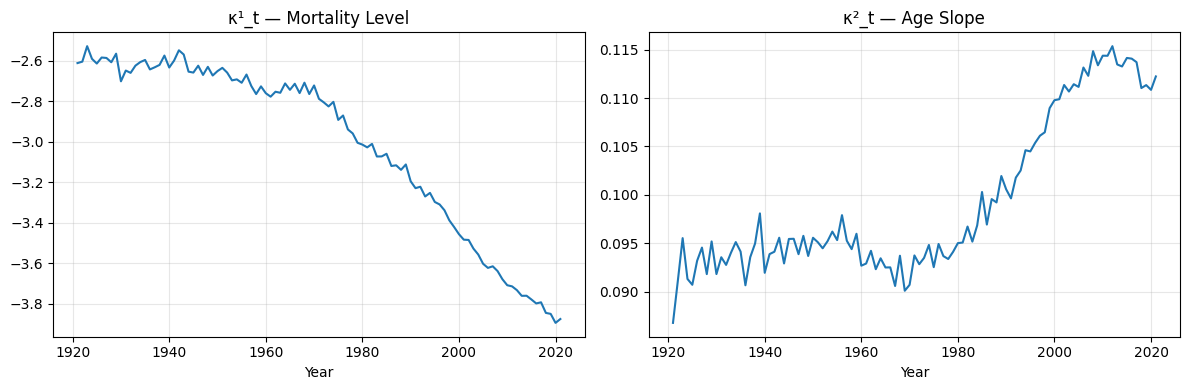

In [4]:
years = sorted(df_cbd['Year'].unique())
kappa1 = []
kappa2 = []

for yr in years:
    yr_data = df_cbd[df_cbd['Year'] == yr]
    X_yr = yr_data['age_centred'].values.reshape(-1, 1)
    y_yr = yr_data['logit_qx'].values
    
    lr = LinearRegression()
    lr.fit(X_yr, y_yr)
    
    kappa1.append(lr.intercept_)
    kappa2.append(lr.coef_[0])

kappa1 = np.array(kappa1)
kappa2 = np.array(kappa2)
years = np.array(years)

# plot both kappas over time
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(years, kappa1)
axes[0].set_title('κ¹_t — Mortality Level')
axes[0].set_xlabel('Year')
axes[0].grid(True, alpha=0.3)

axes[1].plot(years, kappa2)
axes[1].set_title('κ²_t — Age Slope')
axes[1].set_xlabel('Year')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# fit linear trends to both kappas using post-1950 data
post1950 = years >= 1950

lr1 = LinearRegression()
lr1.fit(years[post1950].reshape(-1, 1), kappa1[post1950])

lr2 = LinearRegression()
lr2.fit(years[post1950].reshape(-1, 1), kappa2[post1950])

# OOS evaluation — refit on pre-2001, forecast 2001-2021
train_years = years[years <= 2000]
test_years = years[years > 2000]

kappa1_train = kappa1[years <= 2000]
kappa2_train = kappa2[years <= 2000]

post1950_train = train_years >= 1950
lr1_oos = LinearRegression()
lr1_oos.fit(train_years[post1950_train].reshape(-1, 1), kappa1_train[post1950_train])

lr2_oos = LinearRegression()
lr2_oos.fit(train_years[post1950_train].reshape(-1, 1), kappa2_train[post1950_train])

kappa1_fore = lr1_oos.predict(test_years.reshape(-1, 1))
kappa2_fore = lr2_oos.predict(test_years.reshape(-1, 1))

# generate predicted logit_qx for test period
ages_cbd = np.arange(60, 90)
actual_list, predicted_list = [], []

for i, yr in enumerate(test_years):
    for age in ages_cbd:
        age_c = age - x_bar
        pred_logit = kappa1_fore[i] + kappa2_fore[i] * age_c
        actual_row = df_cbd[(df_cbd['Year'] == yr) & (df_cbd['Age'] == age)]
        if len(actual_row) > 0:
            actual_list.append(actual_row['logit_qx'].values[0])
            predicted_list.append(pred_logit)

actual_arr = np.array(actual_list)
predicted_arr = np.array(predicted_list)

mae_cbd = mean_absolute_error(actual_arr, predicted_arr)
rmse_cbd = np.sqrt(mean_squared_error(actual_arr, predicted_arr))

print("CBD Model OOS Performance (ages 60-89, logit scale):")
print(f"Test MAE:  {mae_cbd:.4f}")
print(f"Test RMSE: {rmse_cbd:.4f}")

CBD Model OOS Performance (ages 60-89, logit scale):
Test MAE:  0.1998
Test RMSE: 0.2218


In [7]:
# convert predictions back to log mortality scale for fair comparison
# logit(qx) -> qx -> mx -> log(mx)
actual_mx_list, predicted_mx_list = [], []

for i, yr in enumerate(test_years):
    for age in ages_cbd:
        age_c = age - x_bar
        pred_logit = kappa1_fore[i] + kappa2_fore[i] * age_c
        
        # convert predicted logit -> qx -> mx
        pred_qx = np.exp(pred_logit) / (1 + np.exp(pred_logit))
        pred_mx = pred_qx / (1 - 0.5 * pred_qx)
        pred_log_mx = np.log(pred_mx)
        
        actual_row = df_cbd[(df_cbd['Year'] == yr) & (df_cbd['Age'] == age)]
        if len(actual_row) > 0:
            actual_mx_list.append(np.log(actual_row['mx_total'].values[0]))
            predicted_mx_list.append(pred_log_mx)

actual_mx_arr = np.array(actual_mx_list)
predicted_mx_arr = np.array(predicted_mx_list)

mae_cbd_log = mean_absolute_error(actual_mx_arr, predicted_mx_arr)
rmse_cbd_log = np.sqrt(mean_squared_error(actual_mx_arr, predicted_mx_arr))

print("CBD Model OOS Performance (log mortality scale, ages 60-89):")
print(f"Test MAE:  {mae_cbd_log:.4f}")
print(f"Test RMSE: {rmse_cbd_log:.4f}")
print()
print("CBD covers ages 60-89 only — other models cover ages 0-100")

CBD Model OOS Performance (log mortality scale, ages 60-89):
Test MAE:  0.1972
Test RMSE: 0.2193

CBD covers ages 60-89 only — other models cover ages 0-100
